<a href="https://colab.research.google.com/github/pd-25/ML-algorithm-implements/blob/main/naive_bayes/spam_sms_naive_byes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('spam.csv',encoding='latin-1')


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3152,ham,I tagged MY friends that you seemed to count a...,NaN,NaN,NaN
2757,ham,Yo we are watching a movie on netflix,NaN,NaN,NaN
3617,ham,Hey check it da. I have listed da.,NaN,NaN,NaN
3894,ham,Yes. Last practice,NaN,NaN,NaN
3702,ham,How is my boy? No sweet words left for me this...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)


In [ ]:
df.sample(5)

,v1,v2
3943,ham,"Until 545 lor... Ya, can go 4 dinner together..."
537,ham,Or maybe my fat fingers just press all these b...
4936,ham,G wants to know where the fuck you are
706,ham,So when do you wanna gym harri
5159,ham,No but the bluray player can


In [7]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [8]:
df.sample(5)

,target,text
1949,ham,Wait 2 min..stand at bus stop
5556,ham,Yes i have. So that's why u texted. Pshew...mi...
2399,ham,Oh... Kay... On sat right?
427,ham,Any pain on urination any thing else?
966,ham,I am not sure about night menu. . . I know onl...


In [9]:
#If there are messy data like 'hum', ' hum ', 'HUm' then use this below
# df['target_col'] = df['target_col'].str.strip().str.lower().map({'yes': True, 'no': False})

# df['target'].value_counts()
#as we check suing value_count, the data is only 2 type and clean so we use pandas labelencoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [10]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.isnull().sum()

,0
target,0
text,0


In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(keep="first", inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['target'].value_counts()

,count
target,
0,4516
1,653


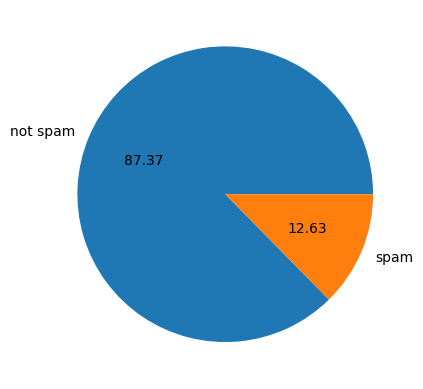

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'], autopct="%0.2f")
plt.show()

In [17]:
#As we get data is imbalanced
#lets create few more column for better performance

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [19]:
df['num_characters'] = df['text'].apply(len)

In [20]:
df.sample(5)

,target,text,num_characters
5237,1,Someonone you know is trying to contact you vi...,155
2860,0,I am not at all happy with what you saying or ...,51
2349,0,Yar else i'll thk of all sorts of funny things.,47
862,0,"Sorry, I guess whenever I can get a hold of my...",95
1858,0,"Sir, i am waiting for your call.",32


In [21]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [22]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [23]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


# Now Data Preprocessing
1. Lower case
2. Tokenization (nltk.word_tokenize)
3. Removing Special char
4. Removing stop words and pantuatons (nltk corpus stop words and string pantuations)
5. stemming (nltk stem)

In [44]:
import string
# nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
from nltk.corpus import stopwords
def transform_text(text: str):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

In [46]:
transform_text('Hello, this is not a &% spamming happening comment?')

'hello spam happen comment'

In [48]:
df['transformed_text'] = df['text'].apply(transform_text)

In [50]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
5345,0,Wat Ì_ doing now?,17,5,1,wat
2102,0,Audrie lousy autocorrect,24,3,1,audri lousi autocorrect
3247,0,Also track down any lighters you can find,41,8,1,also track lighter find
2846,1,Free-message: Jamster!Get the crazy frog sound...,157,38,5,jamster get crazi frog sound poli text mad1 re...
4224,0,\The world suffers a lot... Not because of the...,115,26,2,world suffer lot violenc bad peopl silenc good...


Now we basically work with target and transformed_text feature going forward, we still have the other colm, if we need to to do any bacatrack.

# Now will create a word cloud to highlight which word spam is mostly used here

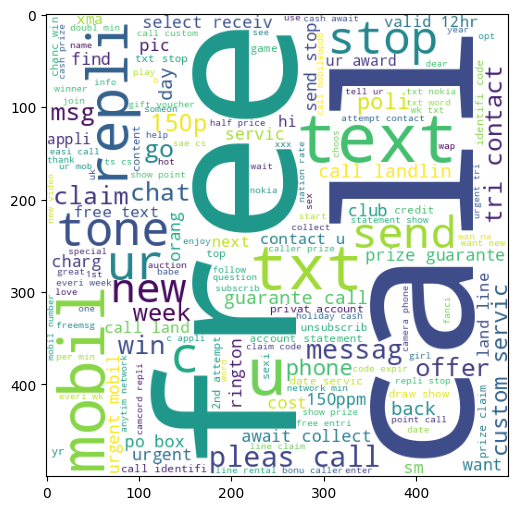

In [54]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

# Now we need on spam colums, use the generate function on spam transformed_text
# df[df['target']==1]['transformed_text']

wc_spam = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_spam)

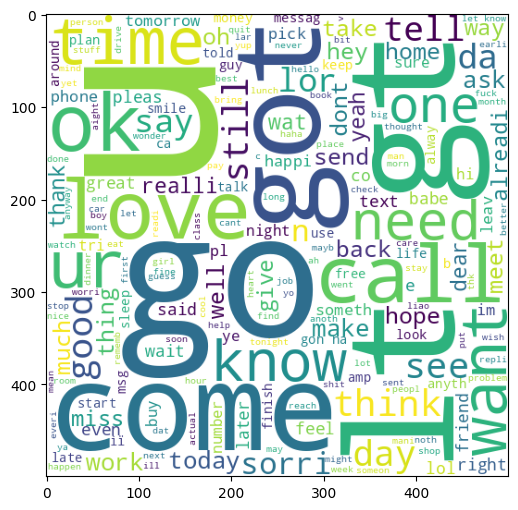

In [55]:
#Now check for ham msg
wc_ham = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_ham)